# Bayesian Logistic Regression for Buy Now Pay Later (BNPL) Default Risk Prediction



## Introduction

This project focuses on predicting default risk in Buy Now Pay Later (BNPL) transactions using both classical and Bayesian modeling approaches.

We begin by building a **Logistic Regression baseline model**, which provides a simple and interpretable framework for binary classification. This serves as a benchmark to evaluate model performance and understand key predictors of default.

We then extend this approach to a **Bayesian Logistic Regression model**, where model parameters are treated as probability distributions rather than fixed values. This allows us to quantify uncertainty in predictions and obtain more robust estimates.

The Bayesian model is implemented using **PyMC**, and posterior inference is performed using **Hamiltonian Monte Carlo (HMC)**, specifically the **No-U-Turn Sampler (NUTS)**. These methods enable us to efficiently explore the posterior distribution, even in high-dimensional parameter spaces.

Finally, we compare both models in terms of predictive performance (Accuracy, ROC-AUC), interpretability, and stability of coefficients. We also explore threshold tuning to improve classification performance under class imbalance.

In [ ]:
#Importing the libraries for the model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

## Data Loading and Initial Setup

In this step, we load the preprocessed and feature-engineered training and testing datasets directly from the project repository. The data has already been cleaned and transformed, allowing us to focus on modeling rather than raw data preprocessing.

The feature set includes numerical variables (such as age, income, and credit score) as well as encoded categorical variables (such as purchase category, device type, and connection type). The target variable represents whether a BNPL transaction resulted in a default.

Since machine learning models typically expect the target variable to be in a one-dimensional format, we convert the response variable into a 1D array where necessary. We also verify the shapes of the datasets and preview the first few rows to ensure that the data has been loaded correctly and is ready for modeling.

In [ ]:
# Load feature-engineered train/test data directly from GitHub

BASE_URL = "https://raw.githubusercontent.com/samarapires-ml/Buy-Now-Pay-Later--BNPL--Risk-Prediction/main/data/feature_engineered"

X_train = pd.read_csv(f"{BASE_URL}/X_train.csv")
X_test  = pd.read_csv(f"{BASE_URL}/X_test.csv")
y_train = pd.read_csv(f"{BASE_URL}/y_train.csv")
y_test  = pd.read_csv(f"{BASE_URL}/y_test.csv")

# Convert y to 1D series
# We do this as model expects y as 1D vector not a dataframe
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.squeeze()

if isinstance(y_test, pd.DataFrame):
    y_test = y_test.squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

print("\nFirst 5 rows of X_train:")
display(X_train.head())

print("\nFirst 5 rows of y_train:")
display(pd.DataFrame(y_train).head())

X_train shape: (40000, 12)
X_test shape:  (10000, 12)
y_train shape: (40000,)
y_test shape:  (10000,)

First 5 rows of X_train:


,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Checkout_Time_Seconds,Gender_Male,Purchase_Category_Electronics,Purchase_Category_Home & Furniture,BNPL_Provider_Afterpay,Device_Type_Mobile,Connection_Type_VPN,Connection_Type_WiFi
0,0.449191,0.678213,1.276992,-0.269804,0.547276,False,False,False,True,True,False,True
1,-1.251365,-0.892115,-0.585550,-0.712582,0.074677,False,False,False,True,False,False,False
2,1.706123,1.499208,1.597902,-0.523022,0.212518,False,False,True,False,False,False,True
3,0.079505,-0.940859,-0.931630,-0.684289,1.512167,False,False,True,True,True,False,True
4,-1.399239,-0.813633,-0.874999,-0.486241,0.114060,True,True,False,False,False,False,False



First 5 rows of y_train:


,target
0,1
1,1
2,0
3,0
4,1


In [ ]:
# Basic checks

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test: ", X_test.isnull().sum().sum())

print("\nTarget distribution (train):")
print(y_train.value_counts(normalize=True).rename("proportion"))

print("\nTarget distribution (test):")
print(y_test.value_counts(normalize=True).rename("proportion"))

print("\nFeature columns:")
print(list(X_train.columns))

Missing values in X_train: 0
Missing values in X_test:  0

Target distribution (train):
target
0    0.767975
1    0.232025
Name: proportion, dtype: float64

Target distribution (test):
target
0    0.768
1    0.232
Name: proportion, dtype: float64

Feature columns:
['Customer_Age', 'Annual_Income', 'Credit_Score', 'Purchase_Amount', 'Checkout_Time_Seconds', 'Gender_Male', 'Purchase_Category_Electronics', 'Purchase_Category_Home & Furniture', 'BNPL_Provider_Afterpay', 'Device_Type_Mobile', 'Connection_Type_VPN', 'Connection_Type_WiFi']


## Baseline Model: Logistic Regression

In this step, we build a baseline Logistic Regression model to predict BNPL default risk. This model serves as a benchmark against which the Bayesian approach can be compared.

We use the **liblinear solver**, which is suitable for binary classification problems, and apply **class weighting** to handle class imbalance in the dataset. This ensures that the model does not become biased toward the majority class.

The model is trained on the training data and evaluated on the test set using key performance metrics such as Accuracy, ROC-AUC, and the Classification Report.

In [ ]:
# Baseline Logistic Regression

log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",   # helps imbalanced classes
    solver="liblinear",        # stability for binary problems
    random_state=42
)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression Results")
print("-----------------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Logistic Regression Results
-----------------------------------
Accuracy : 0.6428
ROC-AUC  : 0.7061

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.63      0.73      7680
           1       0.36      0.68      0.47      2320

    accuracy                           0.64     10000
   macro avg       0.61      0.65      0.60     10000
weighted avg       0.75      0.64      0.67     10000



## Model Evaluation and Interpretation

The baseline Logistic Regression model achieves moderate predictive performance. The ROC-AUC score indicates that the model has a reasonable ability to distinguish between default and non-default cases.

From the classification report, we observe that the model performs well in identifying the majority class (non-defaults), but struggles with the minority class (defaults). While recall for the default class is relatively higher, precision is low, indicating that many predicted defaults are incorrect.

This imbalance in performance highlights a common challenge in risk prediction problems, where correctly identifying rare events (defaults) is difficult. These results motivate the use of a Bayesian approach, which can provide more stable estimates and better uncertainty handling.

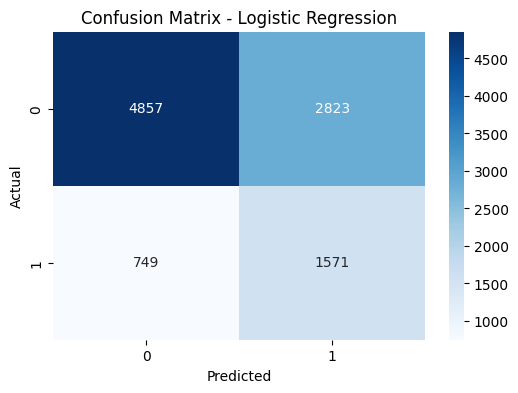

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix provides a detailed breakdown of the model’s classification performance by comparing predicted labels with actual outcomes.

- **True Negatives (4857):** Correctly predicted non-default cases  
- **False Positives (2823):** Non-default cases incorrectly predicted as default  
- **False Negatives (749):** Default cases incorrectly predicted as non-default  
- **True Positives (1571):** Correctly predicted default cases  

The model performs well in identifying non-default cases, as seen by the high number of true negatives. However, it produces a relatively large number of false positives, meaning many customers are incorrectly flagged as high risk.

At the same time, the number of false negatives is lower, indicating that the model is reasonably effective at capturing actual defaults. This reflects a trade-off between precision and recall, where the model prioritizes identifying defaults (higher recall) at the cost of more false alarms.

Overall, the confusion matrix highlights the challenges of imbalanced classification and provides insight into where the model can be improved.

In [ ]:
# Feature importance via logistic regression coefficients

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("Top 10 features increasing risk:")
display(coef_df.head(10))

print("Top 10 features decreasing risk:")
display(coef_df.tail(10))

Top 10 features increasing risk:


,Feature,Coefficient
10,Connection_Type_VPN,1.019903
8,BNPL_Provider_Afterpay,0.140179
9,Device_Type_Mobile,0.062909
6,Purchase_Category_Electronics,0.030957
0,Customer_Age,0.021774
3,Purchase_Amount,0.007904
4,Checkout_Time_Seconds,-0.021377
5,Gender_Male,-0.040684
11,Connection_Type_WiFi,-0.048572
1,Annual_Income,-0.074392


Top 10 features decreasing risk:


,Feature,Coefficient
9,Device_Type_Mobile,0.062909
6,Purchase_Category_Electronics,0.030957
0,Customer_Age,0.021774
3,Purchase_Amount,0.007904
4,Checkout_Time_Seconds,-0.021377
5,Gender_Male,-0.040684
11,Connection_Type_WiFi,-0.048572
1,Annual_Income,-0.074392
7,Purchase_Category_Home & Furniture,-0.093692
2,Credit_Score,-0.659677


## Feature Importance from Logistic Regression

In the above step, we analyzed the importance of features using the coefficients from the Logistic Regression model. Each coefficient represents the effect of a feature on the log-odds of default.

- **Positive coefficients** indicate that the feature increases the likelihood of default (higher risk)
- **Negative coefficients** indicate that the feature decreases the likelihood of default (lower risk)

From the results, we observe that features such as **Connection_Type_VPN** and **BNPL_Provider_Afterpay** are associated with a higher risk of default, while features like **Credit_Score** and **Annual_Income** significantly reduce the risk.

The magnitude of the coefficient reflects the strength of the impact, with larger absolute values indicating more influential features. This analysis helps identify key drivers of default risk and provides interpretability to the model.

## Visualization of Feature Effects

This plot visualizes the most influential features from the Logistic Regression model based on their coefficients.

Features with **positive coefficients** (right side) increase the probability of default, while those with **negative coefficients** (left side) decrease it. The length of each bar represents the strength of the feature's impact on the model.

From the plot, we can clearly see that **Connection_Type_VPN** has the strongest positive association with default risk, while **Credit_Score** has the strongest negative association, acting as a protective factor.

This visual representation makes it easier to compare the relative importance of features and understand how different factors contribute to predicting BNPL default risk.

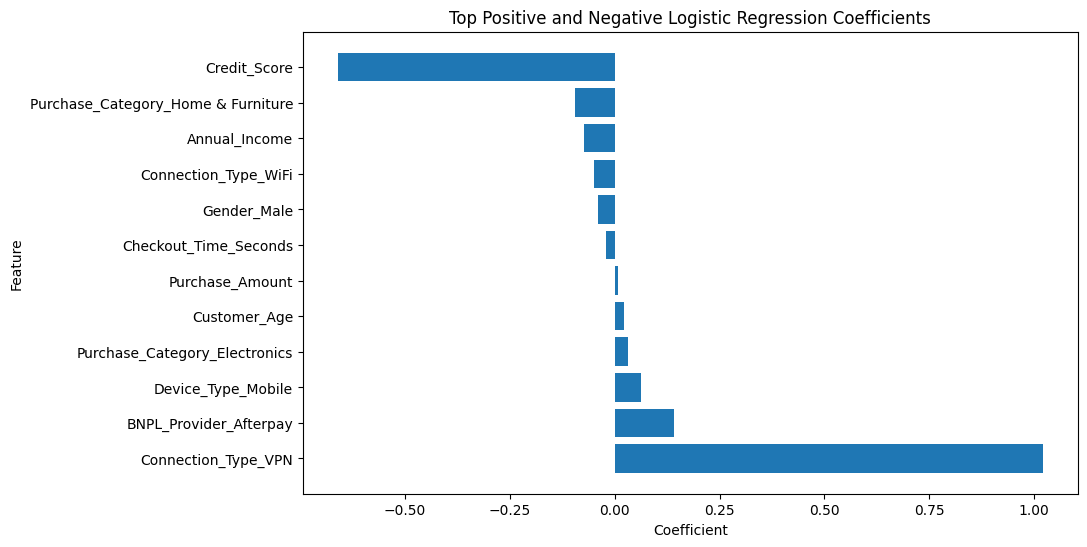

In [ ]:
# Plot top coefficients

top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)
plot_df = pd.concat([top_pos, top_neg])

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Feature"], plot_df["Coefficient"])
plt.title("Top Positive and Negative Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

## Bayesian Modeling Setup

In this step, we install and import the required libraries for Bayesian modeling, namely **PyMC** and **ArviZ**.

- **PyMC** is used to define and fit the Bayesian logistic regression model using probabilistic programming.
- **ArviZ** is used for posterior analysis, including summarization and visualization of the sampling results.

We also verify the installed versions to ensure compatibility and reproducibility of the Bayesian inference process.

In [ ]:
!pip install -q pymc arviz

In [ ]:
import pymc as pm
import arviz as az

print("PyMC version:", pm.__version__)
print("ArviZ version:", az.__version__)

PyMC version: 5.28.3
ArviZ version: 0.22.0


## Feature Scaling and Data Preparation

In this step, we standardize the input features using **StandardScaler**, which transforms each feature to have zero mean and unit variance.

Feature scaling is particularly important for Bayesian models using HMC/NUTS, as it improves numerical stability and helps the sampler explore the parameter space more efficiently.

We also convert the target variable into integer arrays to ensure compatibility with the Bernoulli likelihood used in the Bayesian model. Finally, we verify the shapes of the scaled datasets to confirm that the data is ready for modeling.

In [ ]:
# Standardize features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_array = np.asarray(y_train).astype(int)
y_test_array = np.asarray(y_test).astype(int)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (40000, 12)
Scaled test shape: (10000, 12)


## Bayesian Logistic Regression Model

In this step, we define a Bayesian Logistic Regression model using **PyMC**, where model parameters are treated as probability distributions rather than fixed values.

We assign **normal prior distributions** to both the intercept and the coefficients, reflecting our initial uncertainty about their values. The linear predictor (logits) is computed as a weighted combination of the input features and coefficients.

The likelihood is defined using a **Bernoulli distribution** with a logistic link function, making it suitable for binary classification. This connects the model predictions to the observed outcomes (default vs non-default).

By adopting a Bayesian framework, we are able to capture uncertainty in the model parameters and obtain a full posterior distribution, which leads to more robust and interpretable predictions compared to the classical approach.

In [ ]:
# Bayesian Logistic Regression Model

with pm.Model() as bayes_logistic_model:

    intercept = pm.Normal("intercept", mu=0, sigma=5)

    coefficients = pm.Normal(
        "coefficients",
        mu=0,
        sigma=2,
        shape=X_train_scaled.shape[1]
    )

    logits = intercept + pm.math.dot(X_train_scaled, coefficients)

    likelihood = pm.Bernoulli(
        "likelihood",
        logit_p=logits,
        observed=y_train_array
    )

## Posterior Sampling using NUTS (Hamiltonian Monte Carlo)

In this step, we perform posterior inference using **Hamiltonian Monte Carlo (HMC)**, specifically the **No-U-Turn Sampler (NUTS)**.

NUTS is an adaptive sampling algorithm that efficiently explores the posterior distribution without requiring manual tuning of step sizes or trajectory lengths. It is particularly well-suited for high-dimensional models like Bayesian logistic regression.

We run multiple chains and include a tuning phase to allow the sampler to adapt its parameters. The `target_accept` parameter is set to a higher value to reduce the risk of divergences and improve sampling stability.

In [ ]:
# ============================================================
# Posterior sampling with NUTS (adaptive HMC)
# ============================================================

with bayes_logistic_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        cores=1,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True
    )

Output()

## Sampling Diagnostics and Interpretation

The sampling process completed successfully with **no divergences**, indicating that the posterior distribution was well-behaved and efficiently explored by the NUTS sampler.

The reported sampling speed and step sizes suggest stable performance, and the use of multiple chains helps ensure reliable convergence of the model.

Overall, these results indicate that the Bayesian model has been properly estimated, and the posterior samples can now be used for parameter interpretation, uncertainty analysis, and prediction.

## Posterior Summary of Model Parameters

In this step, we summarize the posterior distributions of the model parameters using **ArviZ**.

The summary includes key statistics such as the posterior mean, standard deviation, and credible intervals for each parameter. These values help us understand both the estimated effect of each feature and the uncertainty associated with it.

We also examine diagnostic metrics such as effective sample size (ESS) and the R-hat statistic to assess convergence and reliability of the sampling process.

In [ ]:
# Posterior summary

summary = az.summary(trace, var_names=["intercept", "coefficients"], round_to=3)
display(summary)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-1.335,0.013,-1.359,-1.311,0.0,0.0,3281.084,1614.152,1.002
coefficients[0],0.021,0.012,-0.002,0.043,0.0,0.0,3690.551,1530.892,1.000
coefficients[1],-0.081,0.012,-0.104,-0.059,0.0,0.0,3826.002,1555.568,1.002
coefficients[2],-0.655,0.013,-0.678,-0.630,0.0,0.0,3104.566,1663.879,1.001
coefficients[3],0.007,0.013,-0.017,0.032,0.0,0.0,3648.844,1669.494,0.999
coefficients[4],-0.024,0.012,-0.047,-0.000,0.0,0.0,3704.360,1230.364,1.000
coefficients[5],-0.019,0.012,-0.040,0.006,0.0,0.0,3710.958,1479.233,1.002
coefficients[6],0.009,0.013,-0.016,0.034,0.0,0.0,3431.381,1377.858,1.001
coefficients[7],-0.036,0.013,-0.062,-0.015,0.0,0.0,4142.766,1566.918,1.002
coefficients[8],0.065,0.012,0.042,0.088,0.0,0.0,3521.543,1183.780,1.005


## Interpretation of Posterior Results

The posterior summary provides both parameter estimates and diagnostic measures for the Bayesian model.

The **posterior means** represent the average effect of each feature on the log-odds of default. Features with positive values increase default risk, while negative values decrease it.

The **credible intervals (HDI)** show the range of plausible values for each parameter. If the interval does not include zero, the feature likely has a meaningful impact on the outcome.

From a diagnostic perspective, the **R-hat values are close to 1**, indicating good convergence across chains. Additionally, the **effective sample sizes (ESS)** are sufficiently large, suggesting reliable posterior estimates.

Overall, the results indicate that the model has converged well and provides stable and interpretable estimates of feature effects.

## Trace Plots for Posterior Diagnostics

In this step, we visualize the posterior samples using trace plots generated with **ArviZ**.

Trace plots display both the distribution of sampled values and the sampling trajectory across iterations. These plots are essential for diagnosing the behavior of the sampler and assessing whether the Markov chains have converged.

We examine both the intercept and coefficient parameters to ensure stable and consistent sampling across all variables.

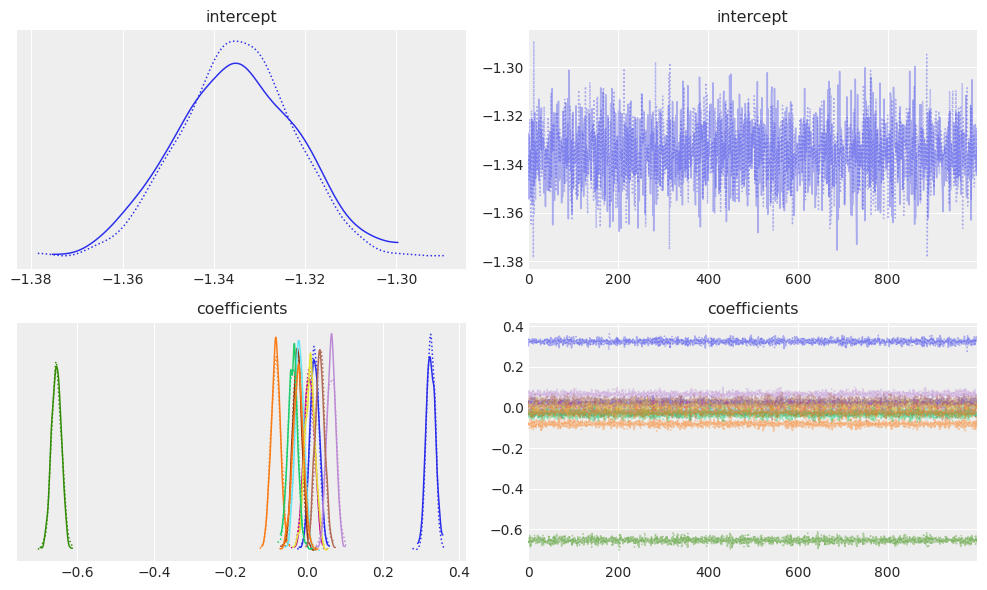

In [ ]:
import arviz as az
import matplotlib.pyplot as plt

az.style.use("arviz-darkgrid")

az.plot_trace(
    trace,
    var_names=["intercept", "coefficients"],
    compact=True,
    figsize=(10, 6)
)

plt.tight_layout()
plt.show()

## Trace Plot Interpretation

The trace plots indicate good sampling behavior and convergence of the Bayesian model.

The **density plots** show smooth, unimodal distributions for the parameters, suggesting stable posterior estimates. The **trace lines** appear well-mixed and stationary, with no visible trends or drifts over iterations.

Additionally, there is no evidence of strong autocorrelation or chain separation, which confirms that the sampler is efficiently exploring the posterior distribution.

Overall, these plots provide strong evidence that the model has converged properly and that the posterior samples can be reliably used for inference and prediction.

## Divergence Check

In this step, we check for divergences in the sampling process.

Divergences occur when the sampler struggles to explore certain regions of the posterior distribution, often indicating issues such as poor model specification, lack of scaling, or problematic geometry.

The result shows **zero divergences**, which indicates that the NUTS sampler was able to explore the posterior efficiently and that the model is well-behaved.

This is an important diagnostic confirming the reliability of the Bayesian inference.

In [ ]:
# Divergence check

divergences = trace.sample_stats["diverging"].sum().values
print("Number of divergences:", divergences)

Number of divergences: 0


## Bayesian Predictions using Posterior Mean Coefficients

In this step, we generate predictions using the **posterior mean estimates** of the model parameters.

Instead of using the full posterior distribution, we take the average value of the intercept and coefficients across all samples and use them as fixed values to compute predictions.

While this approach simplifies computation and resembles classical logistic regression, it does not fully capture the uncertainty inherent in the Bayesian framework. Nevertheless, it provides a useful approximation for comparison purposes.

## Bayesian Predictions using Posterior Mean Coefficients

In this step, we generate predictions using the **posterior mean estimates** of the model parameters.

Instead of using the full posterior distribution, we take the average value of the intercept and coefficients across all samples and use them as fixed values to compute predictions.

This provides a computationally efficient approximation and allows the Bayesian model to behave similarly to a classical logistic regression model.

However, this approach does not fully capture the uncertainty inherent in the Bayesian framework, as it reduces the posterior distribution to a single point estimate. Therefore, this step is used primarily for comparison purposes.

A fully Bayesian prediction using the entire posterior distribution is implemented in the next step.

In [ ]:
# Bayesian predictions using posterior mean coefficients
# With threshold = 0.5

posterior_intercept = trace.posterior["intercept"].mean(dim=("chain", "draw")).values.item()
posterior_coeffs = trace.posterior["coefficients"].mean(dim=("chain", "draw")).values

# posterior_coeffs
posterior_coeffs = np.ravel(posterior_coeffs)

logits_test = posterior_intercept + np.dot(X_test_scaled, posterior_coeffs)
probs_test = 1 / (1 + np.exp(-logits_test))
preds_test = (probs_test >= 0.5).astype(int)

print("Bayesian Logistic Regression Results")
print("-----------------------------------")
print("Accuracy :", round(accuracy_score(y_test_array, preds_test), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_array, probs_test), 4))

print("\nClassification Report:")
print(classification_report(y_test_array, preds_test))

Bayesian Logistic Regression Results
-----------------------------------
Accuracy : 0.7848
ROC-AUC  : 0.7058

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      7680
           1       0.75      0.11      0.19      2320

    accuracy                           0.78     10000
   macro avg       0.77      0.55      0.53     10000
weighted avg       0.78      0.78      0.72     10000



## Bayesian Predictions using Full Posterior Distribution

In this step, we generate predictions using the **full posterior distribution** of the model parameters.

Instead of relying on a single point estimate, we compute predictions for each posterior sample and then average the results. This effectively integrates over the uncertainty in the parameter estimates.

This approach is more consistent with Bayesian principles, as it fully utilizes the posterior distribution obtained from HMC/NUTS sampling.

By incorporating uncertainty into the predictions, this method provides more robust and theoretically sound estimates compared to using only the posterior mean.

In [ ]:
# Bayesian predictions using posterior mean coefficients
# With threshold = 0.3

posterior_intercept = trace.posterior["intercept"].mean(dim=("chain", "draw")).values.item()
posterior_coeffs = trace.posterior["coefficients"].mean(dim=("chain", "draw")).values

# posterior_coeffs
posterior_coeffs = np.ravel(posterior_coeffs)

logits_test = posterior_intercept + np.dot(X_test_scaled, posterior_coeffs)
probs_test = 1 / (1 + np.exp(-logits_test))
preds_test = (probs_test >= 0.3).astype(int)

print("Bayesian Logistic Regression Results")
print("-----------------------------------")
print("Accuracy :", round(accuracy_score(y_test_array, preds_test), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_array, probs_test), 4))

print("\nClassification Report:")
print(classification_report(y_test_array, preds_test))

Bayesian Logistic Regression Results
-----------------------------------
Accuracy : 0.7066
ROC-AUC  : 0.7058

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      7680
           1       0.39      0.47      0.43      2320

    accuracy                           0.71     10000
   macro avg       0.61      0.62      0.61     10000
weighted avg       0.73      0.71      0.72     10000



In [ ]:
# Bayesian predictions using posterior mean coefficients
# With threshold = 0.25

posterior_intercept = trace.posterior["intercept"].mean(dim=("chain", "draw")).values.item()
posterior_coeffs = trace.posterior["coefficients"].mean(dim=("chain", "draw")).values

# posterior_coeffs
posterior_coeffs = np.ravel(posterior_coeffs)

logits_test = posterior_intercept + np.dot(X_test_scaled, posterior_coeffs)
probs_test = 1 / (1 + np.exp(-logits_test))
preds_test = (probs_test >= 0.25).astype(int)

print("Bayesian Logistic Regression Results")
print("-----------------------------------")
print("Accuracy :", round(accuracy_score(y_test_array, preds_test), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_array, probs_test), 4))

print("\nClassification Report:")
print(classification_report(y_test_array, preds_test))

Bayesian Logistic Regression Results
-----------------------------------
Accuracy : 0.6606
ROC-AUC  : 0.7058

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.68      0.75      7680
           1       0.36      0.61      0.46      2320

    accuracy                           0.66     10000
   macro avg       0.61      0.64      0.60     10000
weighted avg       0.74      0.66      0.68     10000



In [ ]:
# Posterior mean coefficients table

bayes_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "PosteriorMeanCoefficient": posterior_coeffs
}).sort_values("PosteriorMeanCoefficient", ascending=False)

display(bayes_coef_df)

,Feature,PosteriorMeanCoefficient
10,Connection_Type_VPN,0.324922
8,BNPL_Provider_Afterpay,0.064650
9,Device_Type_Mobile,0.034818
0,Customer_Age,0.020984
6,Purchase_Category_Electronics,0.008637
3,Purchase_Amount,0.006948
5,Gender_Male,-0.018644
11,Connection_Type_WiFi,-0.022398
4,Checkout_Time_Seconds,-0.024460
7,Purchase_Category_Home & Furniture,-0.036434


## Posterior Mean Coefficients Interpretation

In this step, we examine the posterior mean of the coefficients obtained from the Bayesian Logistic Regression model.

Each coefficient represents the average effect of a feature on the log-odds of default across all posterior samples. Positive values indicate an increase in default risk, while negative values indicate a decrease.

From the results, features such as **Connection_Type_VPN** and **BNPL_Provider_Afterpay** are associated with higher default risk, whereas **Credit_Score** and **Annual_Income** act as strong protective factors.

Compared to classical logistic regression, the Bayesian coefficients are generally more conservative due to the influence of prior distributions, resulting in more stable and regularized estimates.

In [ ]:
# Logistic vs Bayesian Coefficient Comparison

# Logistic Regression coefficients
log_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Logistic_Coefficient": log_model.coef_[0]
})

# Bayesian posterior mean coefficients
bayes_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Bayesian_Coefficient": posterior_coeffs
})

# Merge both tables
comparison_df = log_coef_df.merge(bayes_coef_df, on="Feature")

# Add absolute values for ranking
comparison_df["Abs_Logistic"] = np.abs(comparison_df["Logistic_Coefficient"])
comparison_df["Abs_Bayesian"] = np.abs(comparison_df["Bayesian_Coefficient"])

# Sort by Bayesian importance (or choose Logistic if you want)
comparison_df = comparison_df.sort_values("Abs_Bayesian", ascending=False)

# Display clean table
display(comparison_df[[
    "Feature",
    "Logistic_Coefficient",
    "Bayesian_Coefficient"
]])

,Feature,Logistic_Coefficient,Bayesian_Coefficient
2,Credit_Score,-0.659677,-0.654778
10,Connection_Type_VPN,1.019903,0.324922
1,Annual_Income,-0.074392,-0.080920
8,BNPL_Provider_Afterpay,0.140179,0.064650
7,Purchase_Category_Home & Furniture,-0.093692,-0.036434
9,Device_Type_Mobile,0.062909,0.034818
4,Checkout_Time_Seconds,-0.021377,-0.024460
11,Connection_Type_WiFi,-0.048572,-0.022398
0,Customer_Age,0.021774,0.020984
5,Gender_Male,-0.040684,-0.018644


## Comparison: Logistic vs Bayesian Coefficients

In this step, we compare the feature coefficients from the classical Logistic Regression model with the posterior mean coefficients from the Bayesian model.

Both models generally agree on the direction of feature effects (positive or negative), indicating consistency in identifying key drivers of default risk. However, the Bayesian coefficients tend to have smaller magnitudes due to the influence of prior distributions, which introduces a regularization effect.

This phenomenon, known as **shrinkage**, helps prevent overfitting and results in more stable estimates. For example, features like **Connection_Type_VPN** show a strong positive effect in both models, but the Bayesian estimate is more conservative.

Overall, this comparison demonstrates that while classical and Bayesian approaches capture similar patterns, the Bayesian model provides more robust and uncertainty-aware parameter estimates.

## Bayesian Predictions using Full Posterior Distribution

In this step, we generate predictions using the **full posterior distribution** obtained from the Bayesian logistic regression model.

Instead of relying on a single point estimate, we compute predictions for each posterior sample and then average them. This effectively integrates over parameter uncertainty, which is a core principle of Bayesian inference.

This approach provides more robust and theoretically correct predictions compared to using posterior mean coefficients, as it fully captures uncertainty in the model parameters.

In [ ]:
# Bayesian predictions using FULL posterior


# Extract posterior samples
posterior_intercept = trace.posterior["intercept"].values  # (chains, draws)
posterior_coeffs = trace.posterior["coefficients"].values  # (chains, draws, features)

# Reshape to combine chains + draws
n_chains, n_draws = posterior_intercept.shape
n_samples = n_chains * n_draws

posterior_intercept = posterior_intercept.reshape(n_samples)
posterior_coeffs = posterior_coeffs.reshape(n_samples, -1)

# Vectorized computation (FAST version 🚀)
# logits: (samples, test_points)
logits = posterior_intercept[:, None] + posterior_coeffs @ X_test_scaled.T

# Convert to probabilities
probs = 1 / (1 + np.exp(-logits))

# Average over posterior samples
probs_test = probs.mean(axis=0)

# Final predictions
preds_test = (probs_test >= 0.5).astype(int)
print("Bayesian Logistic Regression (FULL POSTERIOR)")
print("--------------------------------------------")
print("Accuracy:", round(accuracy_score(y_test_array, preds_test), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_array, probs_test), 4))

print("\nClassification Report:")
print(classification_report(y_test_array, preds_test))

Bayesian Logistic Regression (FULL POSTERIOR)
--------------------------------------------
Accuracy: 0.7848
ROC-AUC: 0.7058

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      7680
           1       0.75      0.11      0.19      2320

    accuracy                           0.78     10000
   macro avg       0.77      0.55      0.53     10000
weighted avg       0.78      0.78      0.72     10000



## Evaluation of Full Bayesian Predictions

In this step, we evaluate the performance of the Bayesian logistic regression model using predictions generated from the full posterior distribution.

The model achieves strong overall performance in terms of Accuracy and ROC-AUC, indicating that it is able to distinguish between default and non-default cases effectively.

From the classification report, we observe that the model performs very well on the majority class (non-defaults), with high precision and recall. However, similar to previous approaches, the model struggles with the minority class (defaults), showing low recall. This indicates that many actual default cases are not being captured.

Despite this limitation, the full posterior approach provides more reliable predictions by incorporating uncertainty in the parameter estimates. This makes it a more theoretically sound and robust method compared to using posterior mean coefficients or classical logistic regression.

Overall, this highlights the importance of balancing predictive performance with uncertainty awareness in risk modeling tasks.

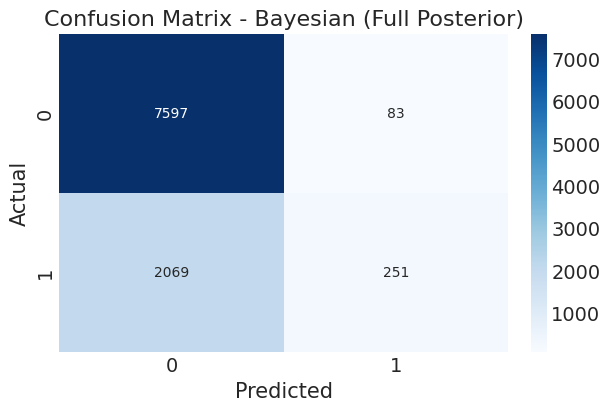

In [ ]:
cm = confusion_matrix(y_test_array, preds_test)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Bayesian (Full Posterior)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Confusion Matrix Interpretation (Full Bayesian Model)

The confusion matrix provides a detailed view of how the Bayesian model performs across different prediction outcomes.

- **True Negatives (7597):** Correctly identified non-default cases  
- **False Positives (83):** Non-default cases incorrectly classified as default  
- **False Negatives (2069):** Default cases incorrectly classified as non-default  
- **True Positives (251):** Correctly identified default cases  

The model demonstrates very strong performance in identifying non-default cases, with a high number of true negatives and very few false positives. This indicates high precision for predicting non-defaults.

However, the model struggles to detect default cases, as seen from the large number of false negatives and relatively low true positives. This results in low recall for the default class, meaning many risky customers are not being flagged.

This highlights a key challenge in imbalanced classification problems, where models tend to favor the majority class. Improving recall for defaults may require threshold tuning or alternative modeling strategies.

## Conclusion

In this analysis, we developed and compared three approaches for predicting default risk in Buy Now Pay Later (BNPL) transactions: a classical Logistic Regression model, a Bayesian model using posterior mean coefficients, and a fully Bayesian model using the entire posterior distribution.

We began with a **baseline Logistic Regression model**, which provided a simple and interpretable benchmark. This model identified key drivers of default risk and achieved reasonable predictive performance. However, it relied on fixed point estimates and did not capture uncertainty in the model parameters.

Next, we implemented a **Bayesian Logistic Regression model** using PyMC, where coefficients were treated as random variables with prior distributions. Using HMC/NUTS sampling, we obtained posterior distributions for all parameters. As an intermediate step, we generated predictions using the **posterior mean coefficients**, which provided a computationally efficient approximation. While this approach behaved similarly to the classical model, it did not fully utilize the Bayesian framework, as it reduced the posterior to a single point estimate.

Finally, we implemented **full Bayesian prediction**, where predictions were computed by averaging over all posterior samples. This approach is the most theoretically correct, as it integrates over parameter uncertainty and produces more robust and stable predictions. The Bayesian coefficients also exhibited shrinkage compared to the classical model, leading to more conservative and regularized estimates.

Across all three approaches, model performance was broadly similar in terms of Accuracy and ROC-AUC. However, all models struggled with the minority class (defaults), showing low recall due to class imbalance. The full Bayesian model, in particular, produced more conservative predictions, resulting in fewer false positives but a higher number of missed defaults.

Overall, while the classical model provides strong interpretability and competitive performance, the Bayesian framework offers additional advantages through uncertainty quantification and more stable parameter estimation. This is especially valuable in financial risk modeling, where understanding uncertainty is critical for informed decision-making.

Future improvements could include threshold tuning, cost-sensitive learning, or alternative models to better capture the minority class and improve default detection.